# ARTI 403 – Image Processing
## Lab 2: Digital Image Fundamentals

**Student ID:** 2240006495

This notebook covers the procedural examples and all required Lab 2 tasks.

## 1. Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['image.cmap'] = 'gray'

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-m2c0cb4i because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. Load Grayscale Images

The two images are stored locally in the same GitHub repository as this notebook.

Image 1 shape: (512, 512)
Image 2 shape: (512, 512)
Data type: uint8


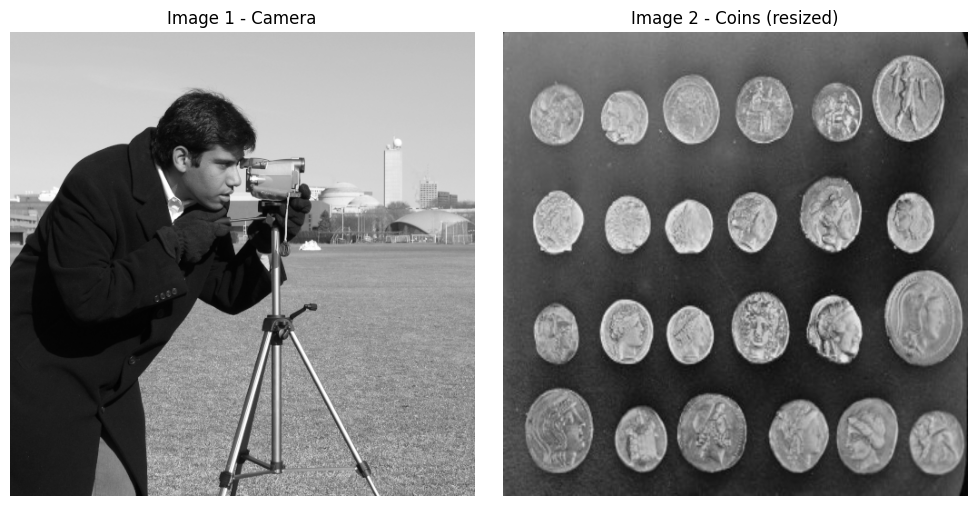

In [2]:
img1 = cv2.imread('camera.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('coins.png', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise FileNotFoundError("Make sure camera.png and coins.png are in the same folder as the notebook.")

# Pixel-by-pixel arithmetic/logical operations require matching dimensions.
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]), interpolation=cv2.INTER_LINEAR)

print('Image 1 shape:', img1.shape)
print('Image 2 shape:', img2.shape)
print('Data type:', img1.dtype)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Image 1 - Camera')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Image 2 - Coins (resized)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Part 1 – Image Sampling and Quantization

The manual demonstrates a sampling factor of **14** and **9** quantization levels.
Task 1 asks to change the parameters and observe their effects, so the changed values below are **7** and **16**.

In [3]:
def sample_image(image, factor):
    height, width = image.shape[:2]
    return cv2.resize(
        image,
        (width // factor, height // factor),
        interpolation=cv2.INTER_NEAREST
    )

def quantize_image(image, levels):
    step = 256 // levels
    quantized = np.floor(image / step) * step
    return np.clip(quantized, 0, 255).astype(np.uint8)

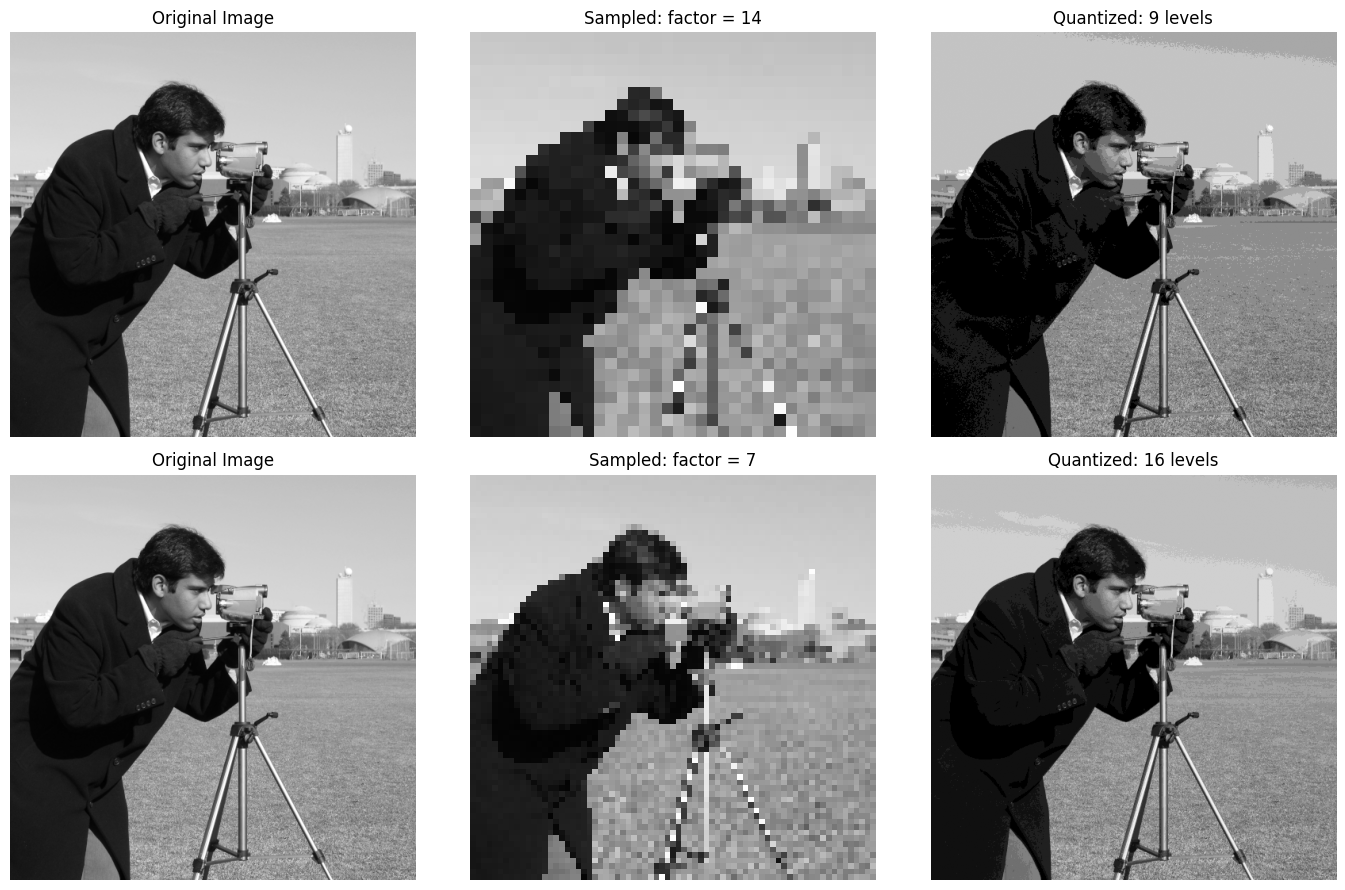

Observation:
- A larger sampling factor removes more spatial detail.
- More quantization levels preserve more gray shades.


In [4]:
# Manual/example parameters
manual_sampling_factor = 14
manual_quantization_levels = 9

# Changed parameters for Task 1
changed_sampling_factor = 7
changed_quantization_levels = 16

sampled_manual = sample_image(img1, manual_sampling_factor)
quantized_manual = quantize_image(img1, manual_quantization_levels)

sampled_changed = sample_image(img1, changed_sampling_factor)
quantized_changed = quantize_image(img1, changed_quantization_levels)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image')
axes[0, 1].imshow(sampled_manual, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Sampled: factor = 14')
axes[0, 2].imshow(quantized_manual, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('Quantized: 9 levels')

axes[1, 0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Original Image')
axes[1, 1].imshow(sampled_changed, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Sampled: factor = 7')
axes[1, 2].imshow(quantized_changed, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('Quantized: 16 levels')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

print('Observation:')
print('- A larger sampling factor removes more spatial detail.')
print('- More quantization levels preserve more gray shades.')

# Part 2 – Arithmetic Operations

The manual first demonstrates addition of two image arrays.  
The final task also requires:
1. Subtracting two images.
2. Adding the constant value **175** to one image.

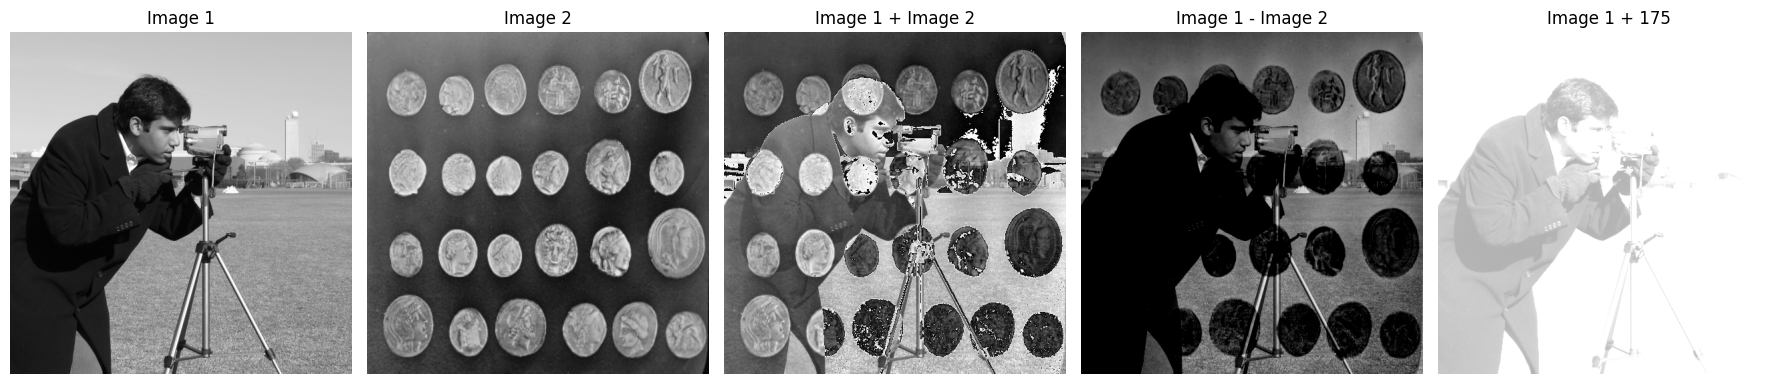

In [5]:
im1arr = np.asarray(img1, dtype=np.uint8)
im2arr = np.asarray(img2, dtype=np.uint8)

# Manual procedural example: add two images
addition_two_images = im1arr + im2arr

# Required Task 2.1: subtract two images
subtraction = cv2.subtract(im1arr, im2arr)

# Required Task 2.2: add constant 175
addition_constant = cv2.add(im1arr, np.full_like(im1arr, 175))

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(im1arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Image 1')
axes[1].imshow(im2arr, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Image 2')
axes[2].imshow(addition_two_images, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Image 1 + Image 2')
axes[3].imshow(subtraction, cmap='gray', vmin=0, vmax=255)
axes[3].set_title('Image 1 - Image 2')
axes[4].imshow(addition_constant, cmap='gray', vmin=0, vmax=255)
axes[4].set_title('Image 1 + 175')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Part 3 – Set and Logical Operations

The manual demonstrates **Union**.  
The final task additionally requires:
1. Set difference
2. Symmetric difference
3. Intersection

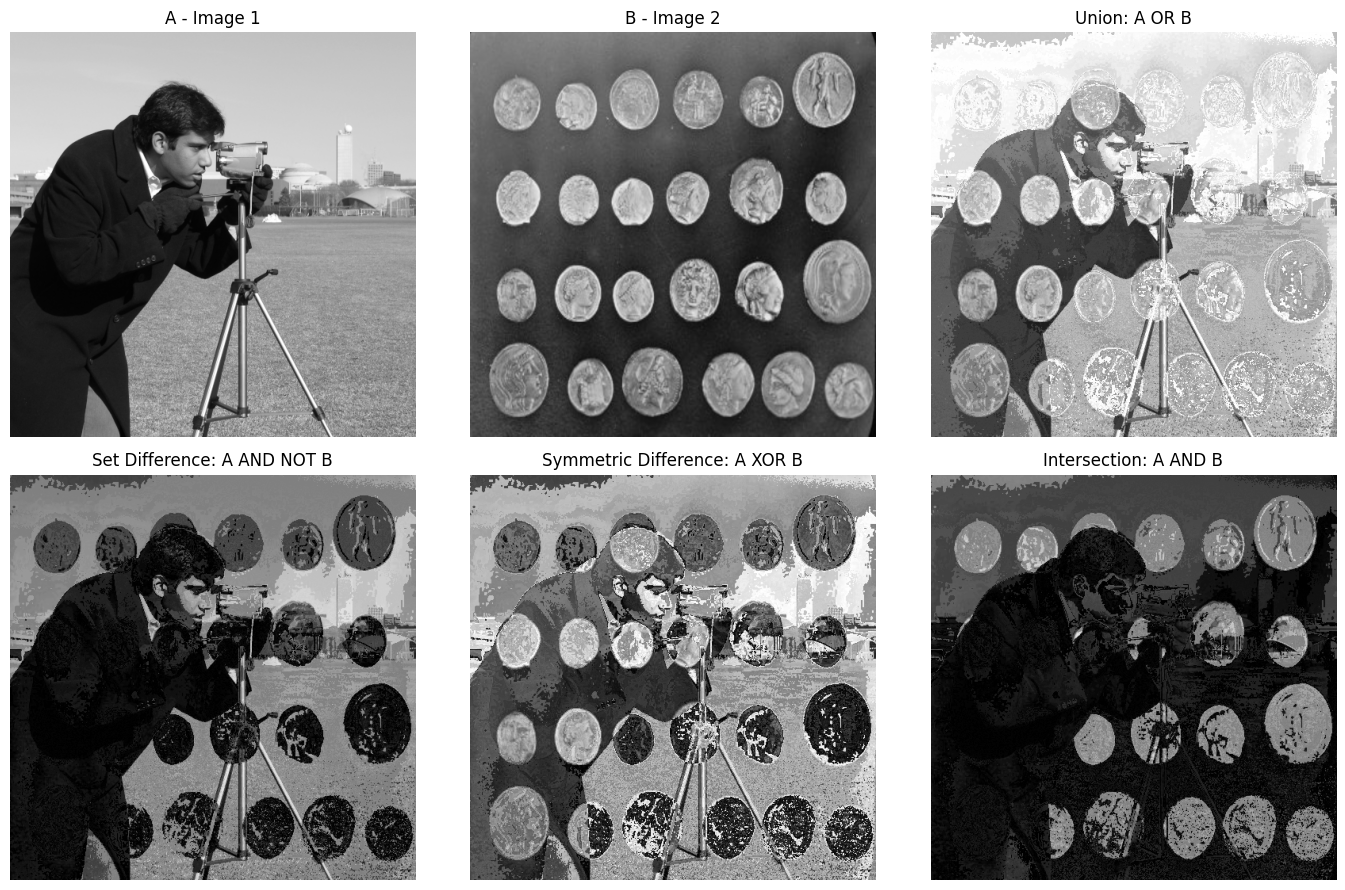

In [6]:
# Manual procedural example: Union
union = np.bitwise_or(im1arr, im2arr)

# Required logical/set operations
set_difference = np.bitwise_and(im1arr, np.bitwise_not(im2arr))
symmetric_difference = np.bitwise_xor(im1arr, im2arr)
intersection = np.bitwise_and(im1arr, im2arr)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(im1arr, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('A - Image 1')
axes[0, 1].imshow(im2arr, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('B - Image 2')
axes[0, 2].imshow(union, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('Union: A OR B')

axes[1, 0].imshow(set_difference, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Set Difference: A AND NOT B')
axes[1, 1].imshow(symmetric_difference, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Symmetric Difference: A XOR B')
axes[1, 2].imshow(intersection, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('Intersection: A AND B')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Conclusion

Completed:
- Sampling and quantization with changed parameters and observations.
- Addition of two images (manual example).
- Subtraction of two images.
- Addition of the constant 175.
- Union (manual example).
- Set difference.
- Symmetric difference.
- Intersection.